# Quality Assessment

In [1]:
import pandas as pd

Load our cleaned DataFrames

In [4]:
# orders_cl.csv
path = 'data/data_cleaned/orders_clean.csv'
orders_cl = pd.read_csv(path, parse_dates = ['created_date'])

# orderlines_cl.csv
path = 'data/data_cleaned/orderlines_clean.csv'
orderlines_cl = pd.read_csv(path, index_col=0, parse_dates = ['date'])

# products_cl.csv
path = 'data/data_cleaned/products_clean.csv'
products_cl = pd.read_csv(path)

In [396]:
orders = orders_cl.copy()
orderlines = orderlines_cl.copy()
products = products_cl.copy()

### Check the data again

Orders:

In [397]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226904 entries, 0 to 226903
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          226904 non-null  int64         
 1   total_paid        226904 non-null  float64       
 2   state             226904 non-null  object        
 3   created_date      226904 non-null  datetime64[ns]
 4   id_order          204691 non-null  float64       
 5   total_unit_price  204691 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 10.4+ MB


Drop unnecessary column 'id_order' in orders (leftover from cleaning):


In [398]:
orders = orders.drop(columns = ['id_order'])


In [399]:
orders.sample(10)

,order_id,total_paid,state,created_date,total_unit_price
59449,358988,1568.00,Completed,2017-05-25 11:14:50,1568.00
110937,410523,83.98,Completed,2017-10-09 16:06:09,79.99
203960,504453,33.98,Place Order,2018-02-02 14:00:37,33.98
54353,353885,1978.99,Shopping Basket,2017-05-08 16:47:13,1978.99
146297,446394,77.66,Shopping Basket,2017-11-26 22:33:32,77.66
24553,324033,64.99,Shopping Basket,2017-02-14 12:56:46,64.99
74442,373988,0.00,Place Order,2017-07-07 09:05:06,NaN
182389,482800,0.00,Shopping Basket,2018-01-05 10:23:40,NaN
220429,520925,0.00,Place Order,2018-03-04 17:56:53,NaN
156598,456827,2711.57,Shopping Basket,2017-12-07 05:27:04,2711.57


Orderlines:

In [400]:
orderlines

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total,date_dt
id,,,,,,,,
1119109,299539,0,1,OTT0133,2017-01-01 00:07:19,18.99,18.99,2017-01-01 00:07:19
1119110,299540,0,1,LGE0043,2017-01-01 00:19:45,399.00,399.00,2017-01-01 00:19:45
1119111,299541,0,1,PAR0071,2017-01-01 00:20:57,474.05,474.05,2017-01-01 00:20:57
1119112,299542,0,1,WDT0315,2017-01-01 00:51:40,68.39,68.39,2017-01-01 00:51:40
1119113,299543,0,1,JBL0104,2017-01-01 01:06:38,23.74,23.74,2017-01-01 01:06:38
...,...,...,...,...,...,...,...,...
1650199,527398,0,1,JBL0122,2018-03-14 13:57:25,42.99,42.99,2018-03-14 13:57:25
1650200,527399,0,1,PAC0653,2018-03-14 13:57:34,141.58,141.58,2018-03-14 13:57:34
1650201,527400,0,2,APP0698,2018-03-14 13:57:41,9.99,19.98,2018-03-14 13:57:41


In [401]:
orderlines.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293983 entries, 1119109 to 1650203
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_order          293983 non-null  int64         
 1   product_id        293983 non-null  int64         
 2   product_quantity  293983 non-null  int64         
 3   sku               293983 non-null  object        
 4   date              293983 non-null  datetime64[ns]
 5   unit_price        293983 non-null  float64       
 6   unit_price_total  293983 non-null  float64       
 7   date_dt           293983 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 20.2+ MB


Drop unneccessary  columns unit_price_num and date_dt from orderlines

In [402]:
orderlines = orderlines.drop(columns = ['date_dt'])
orderlines

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total
id,,,,,,,
1119109,299539,0,1,OTT0133,2017-01-01 00:07:19,18.99,18.99
1119110,299540,0,1,LGE0043,2017-01-01 00:19:45,399.00,399.00
1119111,299541,0,1,PAR0071,2017-01-01 00:20:57,474.05,474.05
1119112,299542,0,1,WDT0315,2017-01-01 00:51:40,68.39,68.39
1119113,299543,0,1,JBL0104,2017-01-01 01:06:38,23.74,23.74
...,...,...,...,...,...,...,...
1650199,527398,0,1,JBL0122,2018-03-14 13:57:25,42.99,42.99
1650200,527399,0,1,PAC0653,2018-03-14 13:57:34,141.58,141.58
1650201,527400,0,2,APP0698,2018-03-14 13:57:41,9.99,19.98


In [403]:
orderlines.isna().sum()

id_order            0
product_id          0
product_quantity    0
sku                 0
date                0
unit_price          0
unit_price_total    0
dtype: int64

Products:

In [404]:
products

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364
...,...,...,...,...,...,...
10152,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,1,12282
10153,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,1,1392
10154,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,1,1392
10155,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,0,1392


In [405]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       10157 non-null  object 
 1   name      10157 non-null  object 
 2   desc      10157 non-null  object 
 3   price     10157 non-null  float64
 4   in_stock  10157 non-null  int64  
 5   type      10110 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 476.2+ KB


## 1.&nbsp; Define Pandas display format

In [406]:
# your code here
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 100)

## 2.&nbsp; Exclude unwanted orders

Some of the orders present in the dataset were left in the shopping cart or cancelled. As the first step of data cleaning, consider excluding them so that, when you analyse the dataset, you deal with actual purchases from which the company is making actual money. Analysing why some orders were cancelled could be very interesting, but it is out of the scope of this project.

In [407]:
# your code here
# print('orders before removing cancelled orders or orders still in the shopping basket')
print('orders before removing everything but completed orders')
print(orders.groupby('state')['state'].value_counts())

#orders = orders[~(orders['state'].isin(['Cancelled', 'Shopping Basket']))]
orders = orders[orders['state'] == 'Completed']

# print('\norders after removing cancelled orders and orders still in the shopping basket')
print('\norders after removing everything but completed orders')
print(orders.groupby('state')['state'].value_counts())



orders before removing everything but completed orders
state
Cancelled            7233
Completed           46605
Pending             14374
Place Order         40883
Shopping Basket    117809
Name: count, dtype: int64

orders after removing everything but completed orders
state
Completed    46605
Name: count, dtype: int64


In [408]:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
Index: 46605 entries, 1 to 226614
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          46605 non-null  int64         
 1   total_paid        46605 non-null  float64       
 2   state             46605 non-null  object        
 3   created_date      46605 non-null  datetime64[ns]
 4   total_unit_price  46560 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 2.1+ MB
None


Secondly, make sure that orders in the dataset are in both orders and orderlines. Otherwise, you might consider orders that do not have products associated with them or products sold without an order that links them with the customers and sellers involved.

In [409]:
# Remove orders with order_ids that don't appear in orderlines
print(orders.shape)
orders = orders.loc[orders['order_id'].isin(orderlines['id_order'])]
print(orders.shape)

(46605, 5)
(46560, 5)


In [410]:
# Remove orderlines with id_orders that don't appear in orders
print(orderlines.shape)
orderlines = orderlines.loc[orderlines['id_order'].isin(orders['order_id'])]
print(orderlines.shape)
print(f"unique orderlines id_order values: {orderlines['id_order'].nunique()}")

(293983, 7)
(62103, 7)
unique orderlines id_order values: 46560


## 3.&nbsp; Exclude orders with unknown products

The products table should be the primary reference for all the products being sold. It is likely that, during the Data Cleaning phase, you deleted many rows from products. Any order involving products not present there is susceptible to containing corrupted information.

You might choose to deal with this in many different ways, but a conservative one would be to delete all of the potentially corrupted rows. 

In [411]:
# your code here

# #find skus from orderlines that do not appear in products
# sku_mask = orderlines['sku'].isin(products['sku'])
# missing_products = orderlines.loc[~sku_mask, 'sku']

# #find id_orders from orderlines that have skus not appearing in products
# missing_mask = orderlines['sku'].isin(missing_products)
# missing_order_ids = orderlines.loc[missing_mask, 'id_order']
# missing_order_ids

# #remove missing order ids from both orders and orderlines
# print('orders')
# print(orders.shape)
# orders = orders[~(orders['order_id'].isin(missing_order_ids))]
# print(orders.shape)

# print('\norderlines')
# print(orderlines.shape)
# orderlines = orderlines[~(orderlines['id_order'].isin(missing_order_ids))]
# print(orderlines.shape)

# !solutions notebook gives 41701 unique order ids


In [412]:
#using the merge approach from the solutions file (because some skus appear in products but without a price)
orderlines_products = orderlines.merge(products, how="left", on = "sku")[["id_order","sku","name"]]
orderlines_products.sample(10)

,id_order,sku,name
1441,304291,MOS0154,Moshi Mini DisplayPort to HDMI Adapter compati...
52787,492504,OTT0139,OtterBox Symmetry Clear Case iPhone SE / 5s / ...
44213,463876,JBL0097,JBL GO Bluetooth Speaker Blue
25039,396247,TUC0332,"Forte Backpack Tucano MacBook Pro 13 ""and 15"" ..."
1367,304026,RUT0009,Orbit runtastic fitness monitor activity and s...
19973,379901,APP1045,Apple USB-C to USB
34127,428277,APP1190,IPhone AppleCare Protection Plan
31793,420284,IFX0035,Full iFixit Battery Kit iPhone 5C battery change
24732,394978,OWC0183,SSD expansion kit OWC Aura Pro 6G 480GB Retina...
49759,480550,BEL0238,Belkin MIXIT spiral cable jack to jack 18m 35m...


In [413]:
#How many missing products?
orderlines_products.name.isna().value_counts()

name
False    60911
True      1192
Name: count, dtype: int64

In [414]:
#remove all orders containing unknown products
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526126, 526298, 526363], dtype=int64)

In [415]:
#keep only orders and orderlines that are not in this list of corrupted orders
orders = orders.loc[~orders.order_id.isin(orders_to_delete),:]
orderlines = orderlines.loc[~orderlines.id_order.isin(orders_to_delete),:]

In [416]:
orders["order_id"].nunique(), orderlines["id_order"].nunique()

(45379, 45379)

## 4.&nbsp; Explore the revenue from different tables

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

(This was already done in the data cleaning step - see 'total_price_orderlines' in orders dataframe)

In [417]:
# your code here
orderlines['unit_price_total'] = orderlines['unit_price']*orderlines['product_quantity']


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [418]:
# your code here
ol_total_price = orderlines.groupby('id_order')['unit_price_total'].sum()
orders = orders.merge(ol_total_price, left_on = 'order_id', right_on = 'id_order')
orders.head()

,order_id,total_paid,state,created_date,total_unit_price,unit_price_total
0,241423,136.15,Completed,2017-11-06 13:10:02,129.16,129.16
1,242832,15.76,Completed,2017-12-31 17:40:03,10.77,10.77
2,243330,84.98,Completed,2017-02-16 10:59:38,77.99,77.99
3,245275,149.00,Completed,2017-06-28 11:35:37,149.00,149.00
4,245595,112.97,Completed,2017-01-21 12:52:47,105.98,105.98


In [419]:
#drop total_unit_price - it's the same as unit_price_total
orders = orders.drop('total_unit_price', axis = 1)
orders.head()

,order_id,total_paid,state,created_date,unit_price_total
0,241423,136.15,Completed,2017-11-06 13:10:02,129.16
1,242832,15.76,Completed,2017-12-31 17:40:03,10.77
2,243330,84.98,Completed,2017-02-16 10:59:38,77.99
3,245275,149.00,Completed,2017-06-28 11:35:37,149.00
4,245595,112.97,Completed,2017-01-21 12:52:47,105.98


### What is the average difference between `total_paid` and `unit_price_total`?

In [420]:
# your code here

orders['price_diff'] = orders['total_paid'] - orders['unit_price_total']
print(f"average difference between 'total_paid' from orders dataset and 'unit_price_total' from orderlines dataset is {round(orders['price_diff'].mean(), 2)} EUR")

average difference between 'total_paid' from orders dataset and 'unit_price_total' from orderlines dataset is 4.27 EUR


### What is the distribution of these differences?

In [421]:
# your code here
print(orders['price_diff'].describe(percentiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count   45379.00
mean        4.27
std        25.03
min      -165.00
25%         0.00
50%         4.99
75%         6.99
90%         6.99
95%         6.99
99%        19.99
max      3984.99
Name: price_diff, dtype: float64


Some values are very large and look unreasonable - define a cutoff for outliers as 1.5*IQR

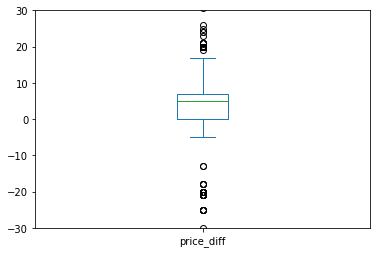

In [422]:
orders['price_diff'].plot.box(ylim = (-30, 30));

In [423]:
Q1 = orders['price_diff'].quantile(0.25)
Q3 = orders['price_diff'].quantile(0.75)

Q1, Q3

(0.0, 6.989999999999981)

In [424]:
IQR = Q3-Q1
IQR

6.989999999999981

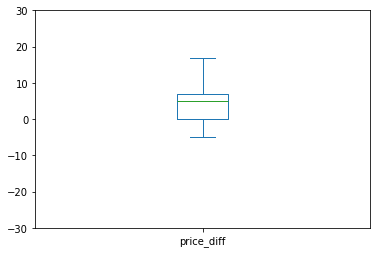

In [425]:
orders_no_outliers = orders.loc[(orders['price_diff'] >= Q1 - 1.5*IQR) & (orders['price_diff']<= Q3 + 1.5*IQR)]
orders_no_outliers['price_diff'].plot.box(ylim = (-30, 30));

In [426]:
print(f'removing {len(orders) - len(orders_no_outliers)} rows with outliers')

removing 728 rows with outliers


In [427]:
#overwrite original orders data to remove outliers
orders = orders_no_outliers

count   44651.00
mean        3.76
std         2.91
min        -5.00
25%         0.00
50%         4.99
75%         6.99
max        16.97
Name: price_diff, dtype: float64


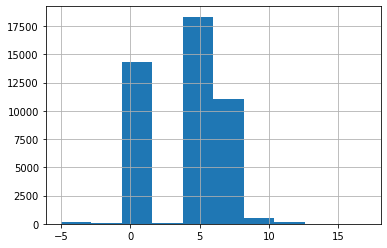

In [428]:
print(orders['price_diff'].describe())
orders['price_diff'].hist();

The max price_diff is 16.97 (the customer paid 16.97 more than the unit_price_total).
It looks like the customer only paid 2 EUR per item for a product that should cost 69.95

In [429]:
orders[orders['price_diff']>16]

,order_id,total_paid,state,created_date,unit_price_total,price_diff
42595,512862,20.97,Completed,2018-02-16 13:01:31,4.00,16.97


In [430]:
orderlines[orderlines['id_order']==512862]


,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total
id,,,,,,,
1616752,512862,0,2,MOP0109,2018-02-16 12:47:23,2.00,4.00


In [431]:
products[products['sku']=='MOP0109']

,sku,name,desc,price,in_stock,type
9944,MOP0109,Mophie Powerstation Mini Universal 4000mAh Bat...,external battery capacity 4000mAh output volta...,69.95,0,1515


Some values are below 0, indicating that the customer paid less than is expected based on the unit_prices from orderlines.
Investigate these:

### Negative price differences:

count   842.00
mean      0.92
std       1.79
min       0.00
25%       0.00
50%       0.01
75%       1.01
90%       5.00
95%       5.00
99%       5.00
max       5.00
Name: price_diff, dtype: float64


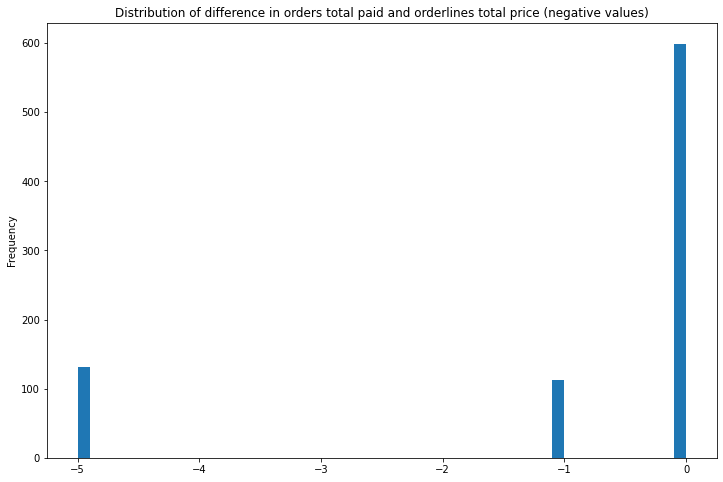

In [432]:
print(orders.loc[orders['price_diff']<0, 'price_diff'].abs().describe(percentiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
#plot the distribution of the price differences below 0
(orders.loc[orders['price_diff']<0, 'price_diff']
       .plot.hist(title = 'Distribution of difference in orders total paid and orderlines total price (negative values)', figsize = (12, 8), bins = 50));

The majority of the negative price differences are close to 0 with very few being greater than -5. It's possible these are from promotional prices/discounts.

Remove outlying orders from orderlines

In [433]:
orders_to_keep = orders['order_id'].unique()
print(orderlines.shape)
orderlines = orderlines.loc[orderlines['id_order'].isin(orders_to_keep)]
print(orderlines.shape)

(59997, 7)
(58888, 7)


In [434]:
orders['order_id'].nunique(), orderlines['id_order'].nunique()

(44651, 44651)

### Positive price differences:

Ignoring very large outliers:

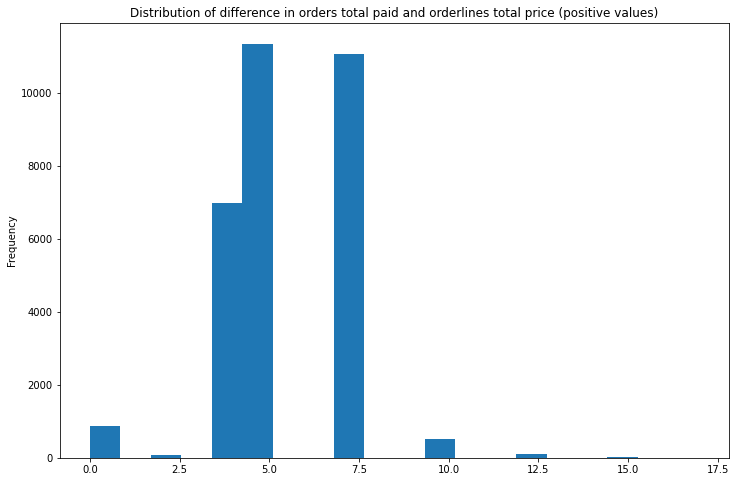

In [435]:
#plot the distribution of the 99% of the data with positive price differences < 20
(orders.loc[(orders['price_diff']<20) & (orders['price_diff']>0), 'price_diff']
       .plot.hist(title = 'Distribution of difference in orders total paid and orderlines total price (positive values)', figsize = (12, 8), bins = 20));

### Add price from products dataset to orderlines for discount analysis

In [436]:
orderlines = orderlines.merge(products[['sku', 'price']], on = 'sku', how = 'left')
orderlines.sample(10)

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total,price
17063,374294,0,1,APP0927,2017-07-07 16:21:24,14.99,14.99,35.00
25328,403694,0,1,MAT0008,2017-09-23 18:30:35,139.00,139.00,169.99
40466,457120,0,1,DLL0058,2017-12-07 14:14:12,1149.99,1149.99,1455.99
39264,450014,0,1,KIN0134,2017-11-27 23:50:46,13.30,13.30,14.99
42838,466538,0,1,MIN0012,2017-12-19 10:12:35,19.99,19.99,24.90
17530,375593,0,1,NOM0022,2017-07-10 20:28:21,39.99,39.99,39.95
42035,464142,0,1,JBL0097,2017-12-15 22:50:00,24.99,24.99,29.99
21230,387852,0,1,LAC0212,2017-08-09 13:13:23,116.79,116.79,139.99
54375,509310,0,2,OWC0224,2018-02-10 14:41:21,49.99,99.98,60.99
27558,411778,0,1,APP2089,2017-10-12 14:00:10,1985.59,1985.59,2105.59


In [437]:
#rename 'price' to 'product_price'
orderlines = orderlines.rename(columns = {'price':'product_price'})
orderlines.sample(10)

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total,product_price
3687,311161,0,1,STA0038,2017-01-17 20:25:40,29.99,29.99,39.99
34690,437373,0,1,LGE0062,2017-11-24 08:22:34,393.86,393.86,449.00
49667,491130,0,1,LAC0180,2018-01-15 10:48:23,82.99,82.99,104.99
31220,424151,0,1,APP0490,2017-11-10 08:55:52,93.60,93.60,109.00
58598,525808,0,1,QNA0252,2018-03-12 10:41:22,439.99,439.99,458.99
48317,485588,0,2,WDT0371,2018-01-08 16:31:21,121.79,243.58,134.99
36310,441688,0,1,SEV0024,2017-11-24 21:48:44,50.99,50.99,599.92
48828,470892,0,1,APP1645,2018-01-10 16:24:59,619.75,619.75,639.00
56763,518097,0,4,SAT0070,2018-02-27 10:25:35,32.99,131.96,34.99
57898,522265,0,1,TOS0018,2018-03-06 16:27:25,49.99,49.99,58.99


Calculate price difference between product_price (without discount) and unit_price (with discount)

count   58888.00
mean       40.51
std        98.52
min      -560.10
25%         5.99
50%        16.00
75%        37.20
max      1511.20
Name: products_price_diff, dtype: float64


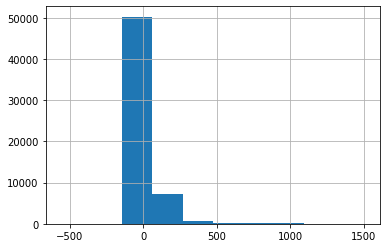

In [438]:
orderlines['products_price_diff'] = orderlines["product_price"] - orderlines["unit_price"]
print(orderlines['products_price_diff'].describe())
orderlines['products_price_diff'].hist();

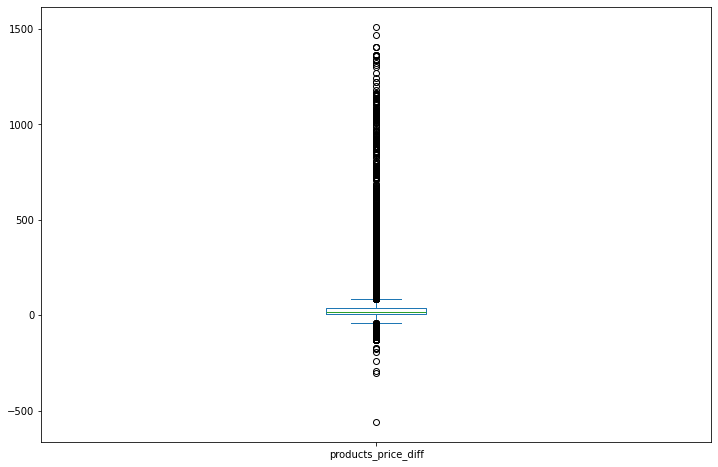

In [439]:
orderlines['products_price_diff'].plot.box(figsize = (12, 8));

In [440]:
orderlines[orderlines['products_price_diff']> 1500]

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total,product_price,products_price_diff
37530,445507,0,1,LAC0223,2017-11-26 16:02:50,8287.80,8287.80,9799.00,1511.20


Large price differences might be reasonable for expensive items.
Look at price difference as a percentage of product_price.

count   58888.00
mean       20.98
std        18.61
min      -212.27
25%         8.04
50%        16.82
75%        27.78
max        99.98
Name: pc_products_price_diff, dtype: float64


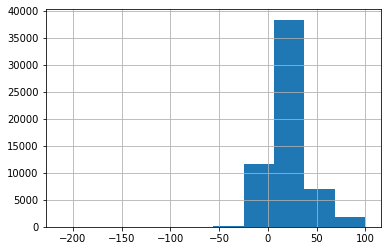

In [441]:
orderlines['pc_products_price_diff'] = (orderlines['products_price_diff']/orderlines['product_price'])*100
print(orderlines['pc_products_price_diff'].describe())
orderlines['pc_products_price_diff'].hist();

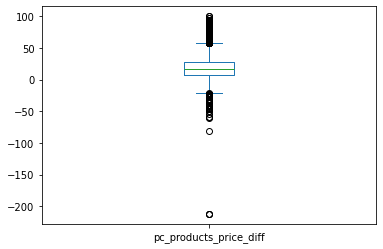

In [442]:
orderlines['pc_products_price_diff'].plot.box();

In [443]:
orderlines[orderlines['pc_products_price_diff']>99]

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total,product_price,products_price_diff,pc_products_price_diff
13340,358440,0,1,SEV0018,2017-05-23 16:21:58,0.01,0.01,19.99,19.98,99.95
13949,359758,0,1,SEV0021,2017-05-31 13:31:24,0.01,0.01,49.99,49.98,99.98


Investigate unusual values.
First - negative prices (-212)

In [444]:
orderlines[orderlines['pc_products_price_diff']<-210]

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total,product_price,products_price_diff,pc_products_price_diff
10879,347233,0,1,IFX0074,2017-04-22 12:20:43,24.95,24.95,7.99,-16.96,-212.27
18870,379925,0,1,IFX0074,2017-07-20 12:27:58,24.95,24.95,7.99,-16.96,-212.27
21427,388586,0,1,IFX0074,2017-08-11 09:29:25,24.95,24.95,7.99,-16.96,-212.27


Remove outliers from orderlines based on pc_products_price_diff

In [453]:
#add index as column to orderlines
orderlines['index'] = orderlines.index
orderlines.sample(10)

,id_order,product_id,product_quantity,sku,date,unit_price,unit_price_total,product_price,products_price_diff,pc_products_price_diff,index
31209,424065,0,1,NOM0024,2017-11-10 06:15:14,53.99,53.99,59.95,5.96,9.94,31209
8557,325290,0,1,PHI0048-A,2017-02-16 15:39:56,58.54,58.54,79.95,21.41,26.78,8557
2903,308888,0,1,MOS0183,2017-01-13 15:49:13,29.99,29.99,40.00,10.01,25.03,2903
1052,301975,0,1,SAM0074,2017-01-05 10:28:06,155.99,155.99,179.99,24.00,13.33,1052
53317,504869,0,1,APP1919,2018-02-03 12:49:39,56.00,56.00,59.00,3.00,5.08,53317
56651,517773,0,2,NTE0013,2018-02-26 16:38:32,19.99,39.98,26.99,7.00,25.94,56651
33460,433104,0,1,APP1190,2017-11-23 01:41:24,51.00,51.00,70.00,19.00,27.14,33460
31901,426774,0,1,WOE0007,2017-11-14 15:06:59,8.99,8.99,9.99,1.00,10.01,31901
50663,495022,0,1,WAC0055,2018-01-20 12:46:21,22.99,22.99,24.90,1.91,7.67,50663
35154,438619,0,1,OWC0039-2,2017-11-24 11:54:31,79.04,79.04,93.98,14.94,15.90,35154


8.036716503164874 27.780864540504503


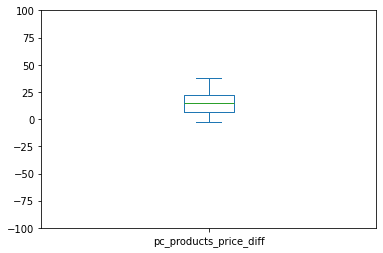

In [454]:
Q1 = orderlines['pc_products_price_diff'].quantile(0.25)
Q3 = orderlines['pc_products_price_diff'].quantile(0.75)

print(Q1, Q3)
orderlines_no_outliers = orderlines.loc[(orderlines['pc_products_price_diff'] >= Q1 - 1.5*IQR) & (orderlines['pc_products_price_diff']<= Q3 + 1.5*IQR)]
orderlines_no_outliers['pc_products_price_diff'].plot.box(ylim = (-100, 100));

In [455]:
orderlines_no_outliers['pc_products_price_diff'].describe()

count   49457.00
mean       15.22
std         9.84
min        -2.45
25%         7.05
50%        14.56
75%        22.32
max        38.26
Name: pc_products_price_diff, dtype: float64

Remove entire orders from `orderlines` and `orders` after removing outliers from `orderlines`

In [456]:
orders_to_remove = orderlines.loc[~(orderlines['index']).isin(orderlines_no_outliers['index']), 'id_order'].unique()
#orders_to_remove = orderlines.loc[(orderlines['pc_products_price_diff'] < Q1 - 1.5*IQR) | (orderlines['pc_products_price_diff'] > Q3 + 1.5*IQR),'id_order']

In [458]:
len(orders_to_remove)

8419

In [461]:
print(orders['order_id'].nunique())
orders = orders[~(orders['order_id'].isin(orders_to_remove))]
print(orders['order_id'].nunique())

44651
36232


In [462]:
print(orderlines['id_order'].nunique())
orderlines = orderlines[~(orderlines['id_order'].isin(orders_to_remove))]
print(orderlines['id_order'].nunique())

44651
36232


count   59997.00
mean       21.23
std        18.67
min      -212.27
25%         8.33
50%        17.24
75%        28.28
max        99.98
Name: pc_products_price_diff, dtype: float64


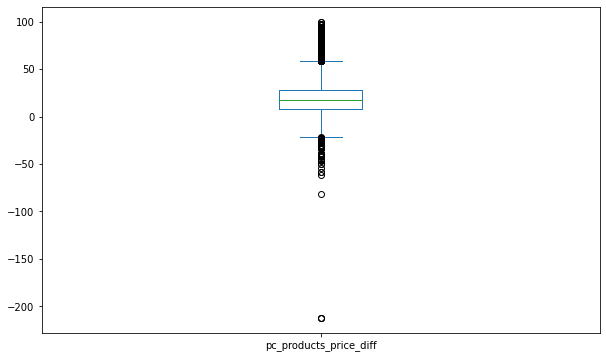

In [368]:
#Look at outliers
print(orderlines['pc_products_price_diff'].describe())
orderlines['pc_products_price_diff'].plot.box(figsize = (10, 6));

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

*your explanation here*

We don't know the shipping costs (I think?) but it's unlikely that all of them can be explained by shipping costs.

Possibly some of the negative price differences are due to voucher payments or managers offering free/discounted product beyond the normal discount (e.g. for customer complaints?).

The positive price differences suggest that the customer paid more than total price - most of these could be explained by shipping costs (6.99 or less). One product was priced at 69.95 in the products price, was sold for 2 EUR in the unit_price and the customer paid 16.97 extra (possibly for shipping).


### If there are differences that you can’t explain: what should you do with these orders?

If the difference is extreme, drop it from the data as it could be corrupted data.
If it's not extreme, keep it in but bear in mind that it could impact our results.

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

In [ ]:
# your thoughts & code here

# Average discount on products was ~15%
# Many values in price columns are possibly corrupted (data entry quality control needed)
# Originally we had 46605 completed orders before data cleaning and quality control
# Now we have 44651 completed orders (or 35089 if we remove the outliers from pc_products_price_diff)
# (losing 4.2% or 24.7% of orders from original data)

# We decided to remove the outliers from pc_products_price_diff to be conservative with our analysis.
# We should mention this in our presentation.

Do not forget to download your quality controlled DataFrames

In [464]:
#from google.colab import files

orders.to_csv("data_cleaned/orders_qu.csv", index=False)
#files.download("orders_qu.csv")

orderlines.to_csv("data_cleaned/orderlines_qu.csv", index=False)
#files.download("orderlines_qu.csv")